# Adversarial attacks on an image classifier

This notebook loads a small pretrained victim CNN and a committed MNIST sample, then attacks the classifier with the fast gradient sign method (FGSM), the basic iterative method (BIM), projected gradient descent (PGD), and the iterative least-likely-class attack. It measures how accuracy collapses as the L-infinity perturbation budget epsilon grows, and shows adversarial examples that are visually almost unchanged yet misclassified.

Everything here runs offline from committed artifacts, no download and no training. The same run is available from the command line with `python scripts/sweep.py --config configs/mnist_sweep.json`.

In [1]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from advattack.config import ATTACK_LABELS, build_attack
from advattack.data import load_sample
from advattack.model import SmallCNN
from advattack.train import accuracy, robust_accuracy, set_seed

set_seed(0)

## Load the pretrained victim and the committed sample

The victim weights live in `models/victim_mnist.pt` and the image sample in `data/sample_mnist.npz`. Both are small and committed to the repository.

In [2]:
model = SmallCNN()
model.load_state_dict(torch.load('../models/victim_mnist.pt', map_location='cpu'))
model.eval()

images, labels = load_sample('../data/sample_mnist.npz')
loader = DataLoader(TensorDataset(images, labels), batch_size=128, shuffle=False)
print('sample size:', len(labels))
print('clean accuracy:', round(accuracy(model, loader), 4))

sample size: 1000
clean accuracy: 0.959


## Robustness vs epsilon

For each budget we measure accuracy under all four attacks. PGD starts from a random point inside the epsilon-ball, so we reseed before each measurement to keep the sweep reproducible. The iterative methods search harder than single-step FGSM, so they drive accuracy lower at the same epsilon.

In [3]:
EPSILONS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
ATTACKS = ['fgsm', 'bim', 'pgd', 'least_likely']
curves = {name: [] for name in ATTACKS}
for eps in EPSILONS:
    for name in ATTACKS:
        set_seed(0)
        acc = robust_accuracy(model, loader, build_attack(name, eps, steps=10))
        curves[name].append(acc)
    print(f'eps={eps:.2f}', {k: round(v[-1], 3) for k, v in curves.items()})

eps=0.00 {'fgsm': 0.959, 'bim': 0.959, 'pgd': 0.959, 'least_likely': 0.959}


eps=0.05 {'fgsm': 0.905, 'bim': 0.889, 'pgd': 0.888, 'least_likely': 0.952}


eps=0.10 {'fgsm': 0.802, 'bim': 0.718, 'pgd': 0.709, 'least_likely': 0.931}


eps=0.15 {'fgsm': 0.607, 'bim': 0.4, 'pgd': 0.374, 'least_likely': 0.869}


eps=0.20 {'fgsm': 0.388, 'bim': 0.103, 'pgd': 0.08, 'least_likely': 0.626}


eps=0.25 {'fgsm': 0.214, 'bim': 0.007, 'pgd': 0.004, 'least_likely': 0.259}


eps=0.30 {'fgsm': 0.09, 'bim': 0.0, 'pgd': 0.0, 'least_likely': 0.047}


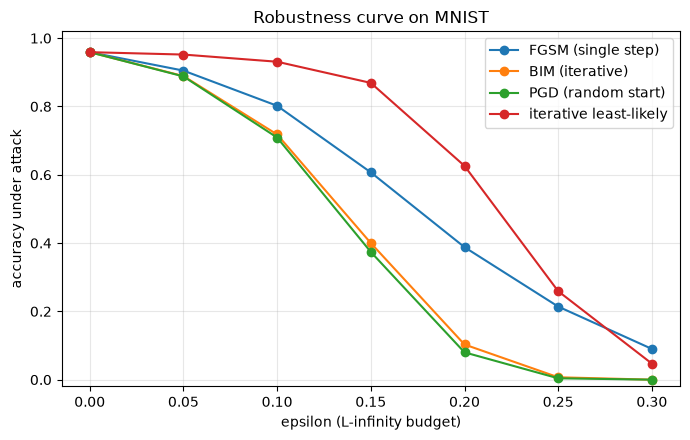

In [4]:
plt.figure(figsize=(7, 4.5))
for name in ATTACKS:
    plt.plot(EPSILONS, curves[name], marker='o', label=ATTACK_LABELS[name])
plt.xlabel('epsilon (L-infinity budget)')
plt.ylabel('accuracy under attack')
plt.ylim(-0.02, 1.02)
plt.title('Robustness curve on MNIST')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Adversarial examples

Top row: clean digits with the model's prediction. Bottom row: the same digits after a PGD perturbation of epsilon=0.2, with the new prediction. The perturbations are small in pixel space but flip the predictions.

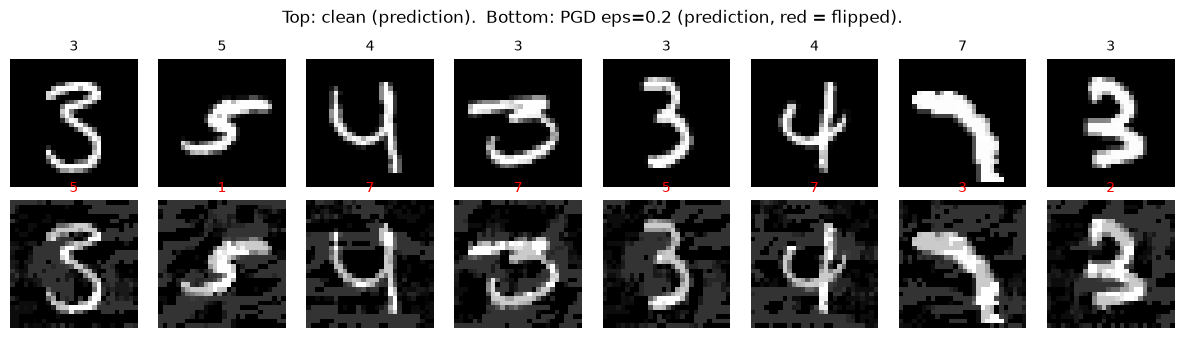

In [5]:
x, y = images[:8], labels[:8]
set_seed(0)
x_adv = build_attack('pgd', 0.2, steps=10)(model, x, y)
with torch.no_grad():
    clean_pred = model(x).argmax(dim=1)
    adv_pred = model(x_adv).argmax(dim=1)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for i in range(8):
    axes[0, i].imshow(x[i, 0], cmap='gray', vmin=0, vmax=1); axes[0, i].axis('off')
    axes[0, i].set_title(f'{int(clean_pred[i])}', fontsize=10)
    axes[1, i].imshow(x_adv[i, 0], cmap='gray', vmin=0, vmax=1); axes[1, i].axis('off')
    flipped = int(adv_pred[i]) != int(y[i])
    axes[1, i].set_title(f'{int(adv_pred[i])}', fontsize=10, color='red' if flipped else 'black')
fig.suptitle('Top: clean (prediction).  Bottom: PGD eps=0.2 (prediction, red = flipped).')
plt.tight_layout()
plt.show()